# 🎵 Music21 Tutorial: Composing, Notation, & MusicXML in Jupyter

Welcome to this interactive tutorial on **music21** using Jupyter Notebook!

### Tutorial Outline:
1. **Setup & Environment**: Importing music21 and verifying notation renderers.
2. **Music21 Building Blocks**: Creating Notes, Pitches, Durations, Chords, and Streams.
3. **Composing a Complete Piece**: Step-by-step composition of Beethoven's **"Ode to Joy" in the Key of C Major** with melody and bass harmony.
4. **Showing Music Notation**:
   - 📜 **Hierarchical Text Stream Tree** (`score.show('text')`)
   - 🎼 **Inline High-Resolution Vector SVG Notation** (using `verovio`)
   - 🖼️ **Engraved Sheet Music Images** (using LilyPond)
5. **Exporting & Importing MusicXML**:
   - Exporting the score to standard `.musicxml`
   - Re-importing with `music21.converter.parse()` and verifying structure.
6. **MIDI Export & Musical Analysis**:
   - Exporting to standard MIDI format
   - Krumhansl-Schmuckler Key Analysis and Pitch Class Histogram.


## 1. Setup & Environment Configuration

In [1]:
import os
import subprocess
from pathlib import Path
import music21 as m21
from IPython.display import display, SVG, Image, HTML
import verovio
import matplotlib.pyplot as plt

print(f"music21 version: {m21.__version__}")
print(f"Verovio version: {verovio.__version__ if hasattr(verovio, '__version__') else 'Installed'}")


/home/codespace/.local/lib/python3.12/site-packages/requests/__init__.py:113: RequestsDependencyWarning: urllib3 (2.6.3) or chardet (7.6.0)/charset_normalizer (3.4.5) doesn't match a supported version!
  warnings.warn(


music21 version: 10.5.0
Verovio version: Installed


## 2. Music21 Core Building Blocks: Notes, Durations, and Chords

In [3]:
# 1. Notes with pitch and duration (expressed in quarterLengths)
c_quarter = m21.note.Note("C4", quarterLength=1.0)   # Quarter note (1 beat)
e_half = m21.note.Note("E4", quarterLength=2.0)      # Half note (2 beats)
g_eighth = m21.note.Note("G4", quarterLength=0.5)    # Eighth note (0.5 beat)
c_dotted = m21.note.Note("C5", quarterLength=1.5)    # Dotted quarter note (1.5 beats)
rest_quarter = m21.note.Rest(quarterLength=1.0)      # Quarter rest

# 2. Creating a Chord
c_major_triad = m21.chord.Chord(["C4", "E4", "G4"], quarterLength=2.0)

print(f"Note Name: {c_quarter.nameWithOctave}, Frequency: {c_quarter.pitch.frequency:.2f} Hz, Duration: {c_quarter.quarterLength} quarter(s)")
print(f"Chord Name: {c_major_triad.pitchedCommonName}, Pitches: {[p.nameWithOctave for p in c_major_triad.pitches]}")


Note Name: C4, Frequency: 261.63 Hz, Duration: 1.0 quarter(s)
Chord Name: C-major triad, Pitches: ['C4', 'E4', 'G4']


## 3. Composing "Ode to Joy" in the Key of C Major

We will now compose Beethoven's famous theme from the 9th Symphony, transposed to the **Key of C Major** for clarity:
- **Melody Part (Treble Clef)**: 16 measures in 4/4 time at 120 BPM.
- **Harmony Part (Bass Clef)**: Accompaniment chords (C Major, G Major, D minor).


In [4]:
def compose_ode_to_joy():
    score = m21.stream.Score()
    
    # 1. Metadata
    score.metadata = m21.metadata.Metadata()
    score.metadata.title = "Ode to Joy (An die Freude)"
    score.metadata.composer = "Ludwig van Beethoven"
    score.metadata.movementName = "Theme from Symphony No. 9 (Arranged in C Major)"
    
    # 2. Melody Part (Right Hand / Soprano)
    melody_part = m21.stream.Part()
    melody_part.id = 'Melody'
    melody_part.partName = 'Melody'
    melody_part.append(m21.clef.TrebleClef())
    melody_part.append(m21.key.Key('C'))
    melody_part.append(m21.meter.TimeSignature('4/4'))
    melody_part.append(m21.tempo.MetronomeMark('Allegro moderato', 120))
    
    # 16-measure melody (notes + durations in beats)
    melody_notes = [
        # Phrase 1 (Measures 1-4)
        ('E4', 1.0), ('E4', 1.0), ('F4', 1.0), ('G4', 1.0),
        ('G4', 1.0), ('F4', 1.0), ('E4', 1.0), ('D4', 1.0),
        ('C4', 1.0), ('C4', 1.0), ('D4', 1.0), ('E4', 1.0),
        ('E4', 1.5), ('D4', 0.5), ('D4', 2.0),
        
        # Phrase 2 (Measures 5-8)
        ('E4', 1.0), ('E4', 1.0), ('F4', 1.0), ('G4', 1.0),
        ('G4', 1.0), ('F4', 1.0), ('E4', 1.0), ('D4', 1.0),
        ('C4', 1.0), ('C4', 1.0), ('D4', 1.0), ('E4', 1.0),
        ('D4', 1.5), ('C4', 0.5), ('C4', 2.0),
        
        # Phrase 3 (Bridge: Measures 9-12)
        ('D4', 1.0), ('D4', 1.0), ('E4', 1.0), ('C4', 1.0),
        ('D4', 1.0), ('E4', 0.5), ('F4', 0.5), ('E4', 1.0), ('C4', 1.0),
        ('D4', 1.0), ('E4', 0.5), ('F4', 0.5), ('E4', 1.0), ('D4', 1.0),
        ('C4', 1.0), ('D4', 1.0), ('G3', 2.0),
        
        # Phrase 4 (Recapitulation: Measures 13-16)
        ('E4', 1.0), ('E4', 1.0), ('F4', 1.0), ('G4', 1.0),
        ('G4', 1.0), ('F4', 1.0), ('E4', 1.0), ('D4', 1.0),
        ('C4', 1.0), ('C4', 1.0), ('D4', 1.0), ('E4', 1.0),
        ('D4', 1.5), ('C4', 0.5), ('C4', 2.0)
    ]
    
    for pitch_str, dur in melody_notes:
        n = m21.note.Note(pitch_str, quarterLength=dur)
        melody_part.append(n)
        
    # 3. Harmony Part (Left Hand / Bass)
    harmony_part = m21.stream.Part()
    harmony_part.id = 'Harmony'
    harmony_part.partName = 'Harmony'
    harmony_part.append(m21.clef.BassClef())
    harmony_part.append(m21.key.Key('C'))
    harmony_part.append(m21.meter.TimeSignature('4/4'))
    
    harmony_chords = [
        # Measures 1-4
        (['C3', 'E3', 'G3'], 4.0), (['G2', 'D3', 'G3'], 4.0),
        (['C3', 'E3', 'G3'], 4.0), (['G2', 'D3', 'G3'], 4.0),
        # Measures 5-8
        (['C3', 'E3', 'G3'], 4.0), (['G2', 'D3', 'G3'], 4.0),
        (['C3', 'E3', 'G3'], 4.0), (['C3', 'E3', 'G3'], 4.0),
        # Measures 9-12
        (['G2', 'D3', 'G3'], 2.0), (['C3', 'E3', 'G3'], 2.0),
        (['G2', 'D3', 'G3'], 2.0), (['C3', 'E3', 'G3'], 2.0),
        (['G2', 'D3', 'G3'], 2.0), (['D3', 'F3', 'A3'], 2.0),
        (['C3', 'E3', 'G3'], 2.0), (['G2', 'B2', 'D3'], 2.0),
        # Measures 13-16
        (['C3', 'E3', 'G3'], 4.0), (['G2', 'D3', 'G3'], 4.0),
        (['C3', 'E3', 'G3'], 4.0), (['C3', 'E3', 'G3'], 4.0)
    ]
    
    for pitches, dur in harmony_chords:
        ch = m21.chord.Chord(pitches, quarterLength=dur)
        harmony_part.append(ch)
        
    score.append(melody_part.makeMeasures())
    score.append(harmony_part.makeMeasures())
    
    return score

score = compose_ode_to_joy()
print(f"✓ Score generated: '{score.metadata.title}' with {len(score.parts)} parts and {len(score.parts[0].getElementsByClass('Measure'))} measures.")


✓ Score generated: 'Ode to Joy (An die Freude)' with 2 parts and 16 measures.


## 4. Showing Music Notation

Below are 3 practical approaches for visualizing music notation in Python and Jupyter:


### Method 1: Hierarchical Text Notation (`score.show('text')`)

In [4]:
# Display first 4 measures in text stream hierarchy
score.measures(1, 4).show('text')


{0.0} <music21.stream.Part 0x79bae6934140>
    {0.0} <music21.stream.Measure 1 offset=0.0>
        {0.0} <music21.clef.TrebleClef>
        {0.0} <music21.tempo.MetronomeMark Allegro moderato Quarter=120>
        {0.0} <music21.key.Key of C major>
        {0.0} <music21.meter.TimeSignature 4/4>
        {0.0} <music21.note.Note E>
        {1.0} <music21.note.Note E>
        {2.0} <music21.note.Note F>
        {3.0} <music21.note.Note G>
    {4.0} <music21.stream.Measure 2 offset=4.0>
        {0.0} <music21.note.Note G>
        {1.0} <music21.note.Note F>
        {2.0} <music21.note.Note E>
        {3.0} <music21.note.Note D>
    {8.0} <music21.stream.Measure 3 offset=8.0>
        {0.0} <music21.note.Note C>
        {1.0} <music21.note.Note C>
        {2.0} <music21.note.Note D>
        {3.0} <music21.note.Note E>
    {12.0} <music21.stream.Measure 4 offset=12.0>
        {0.0} <music21.note.Note E>
        {1.5} <music21.note.Note D>
        {2.0} <music21.note.Note D>
{0.0} <music21.stre

### Method 2: Inline High-Resolution Vector SVG Notation (Verovio)

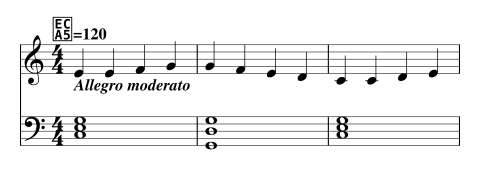

In [5]:
def render_score_svg(score_obj, page=1, scale=40):
    """Renders a score to high-quality SVG using Verovio."""
    xml_path = score_obj.write('musicxml')
    with open(xml_path, 'r', encoding='utf-8') as f:
        xml_data = f.read()
    
    tk = verovio.toolkit()
    tk.setOptions({
        'pageWidth': 1200,
        'pageHeight': 700,
        'scale': scale,
        'adjustPageHeight': True,
        'header': 'none',
        'footer': 'none'
    })
    tk.loadData(xml_data)
    return tk.renderToSVG(page)

# Display the SVG notation directly inside the notebook
svg_content = render_score_svg(score, page=1)
display(SVG(svg_content))


### Method 3: Engraved Sheet Music Image (LilyPond)

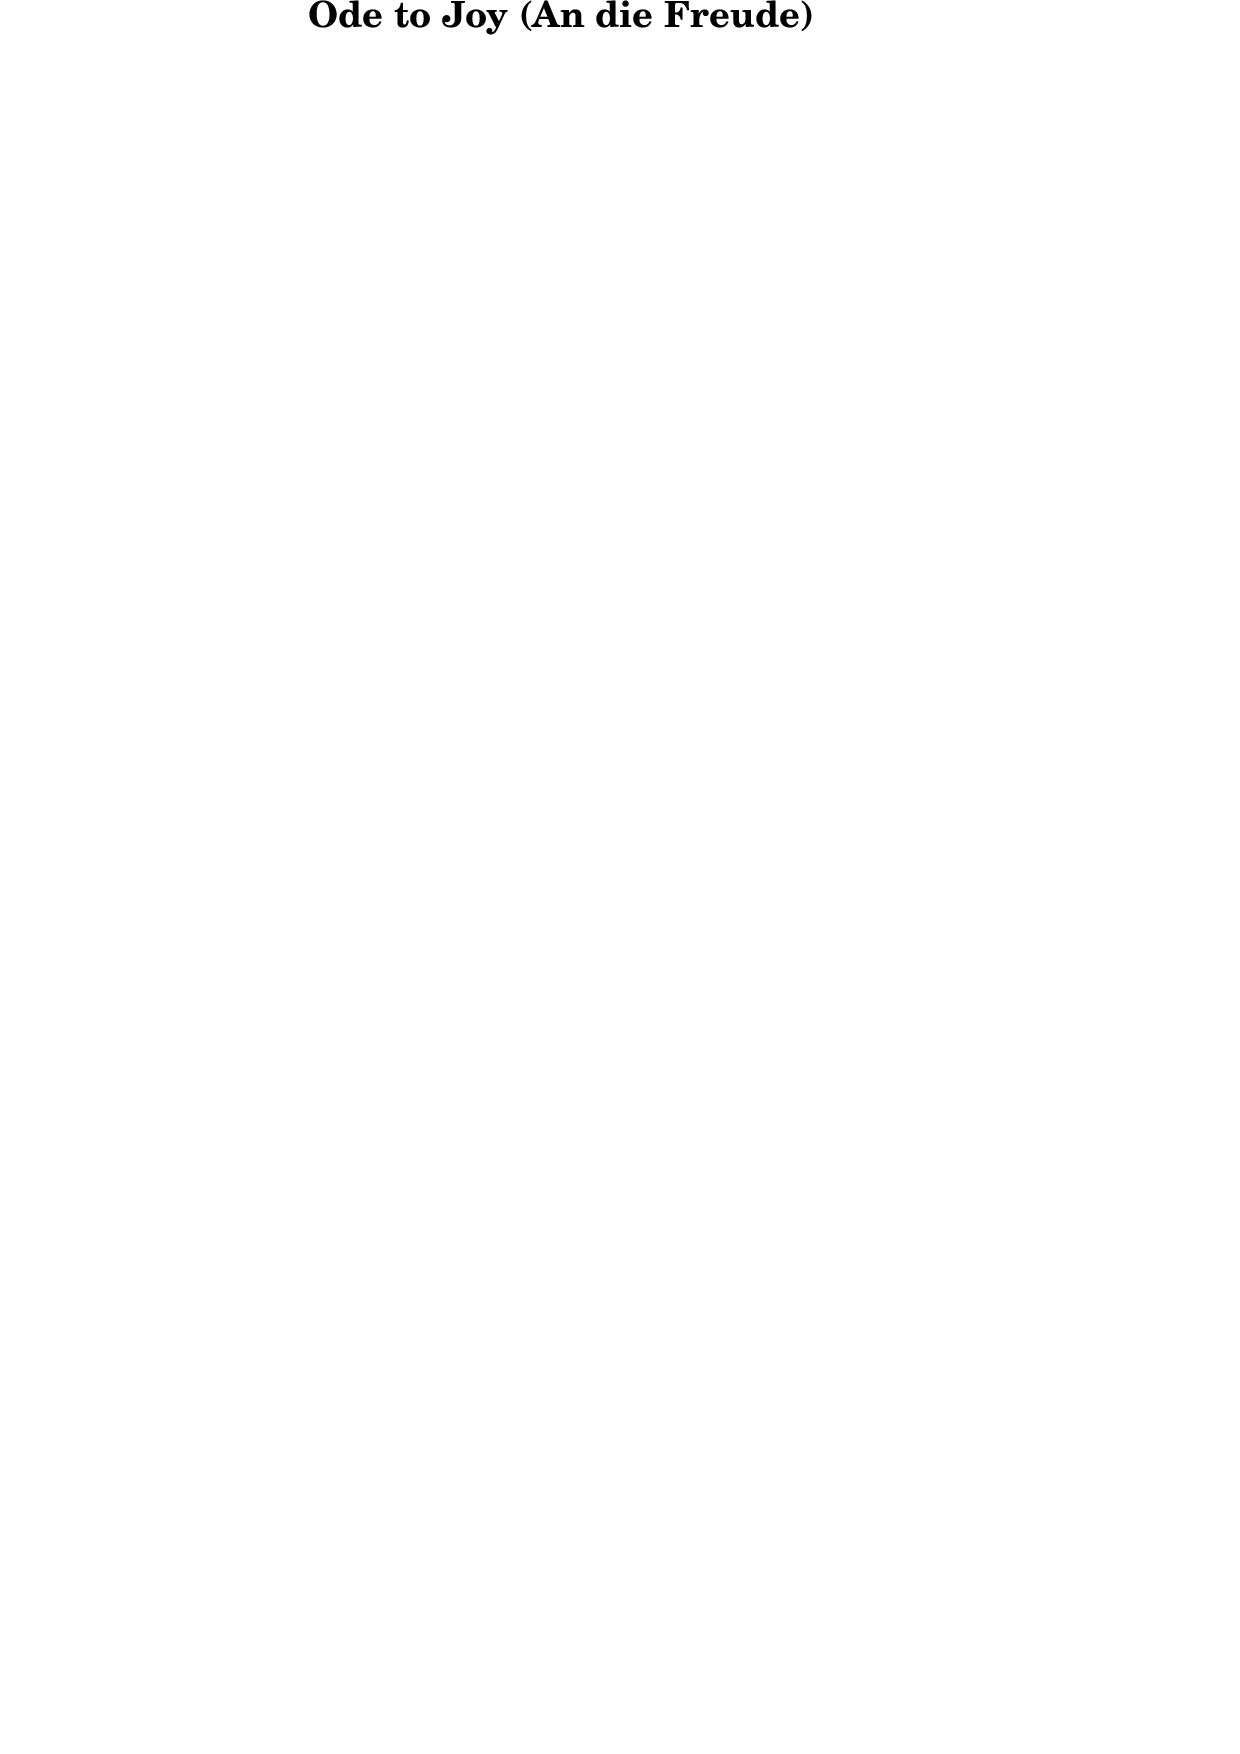

In [6]:
def render_lilypond_png(score_obj, output_base='notebook_score'):
    """Engraves score to PNG using LilyPond."""
    ly_file = score_obj.write('lily', fp=f'{output_base}.ly')
    cmd = ['lilypond', '--png', '-dresolution=150', '-o', output_base, str(ly_file)]
    subprocess.run(cmd, check=True, capture_output=True)
    
    # Locate output png
    png_file = f'{output_base}.png'
    if not os.path.exists(png_file):
        page1 = f'{output_base}-page1.png'
        if os.path.exists(page1):
            png_file = page1
    return png_file

engraved_png = render_lilypond_png(score, 'notebook_ode_to_joy')
display(Image(filename=engraved_png, width=800))


## 5. Exporting & Importing MusicXML

**MusicXML** is the industry standard format for sharing scores across music software such as MuseScore, Finale, Sibelius, and web players.


In [7]:
# 1. Export Score to MusicXML
musicxml_file = 'ode_to_joy_exported.musicxml'
exported_path = score.write('musicxml', fp=musicxml_file)

print(f"✓ MusicXML successfully exported to: {exported_path}")
print(f"✓ File size: {os.path.getsize(exported_path)} bytes")

# Preview first 20 lines of the generated MusicXML
with open(exported_path, 'r', encoding='utf-8') as f:
    preview = [f.readline() for _ in range(20)]
print("\n--- MusicXML Structure Preview ---")
print("".join(preview))


✓ MusicXML successfully exported to: /workspaces/pyMusicPlayground/music21/ode_to_joy_exported.musicxml
✓ File size: 29282 bytes

--- MusicXML Structure Preview ---
<?xml version="1.0" encoding="utf-8"?>
<!DOCTYPE score-partwise  PUBLIC "-//Recordare//DTD MusicXML 4.0 Partwise//EN" "http://www.musicxml.org/dtds/partwise.dtd">
<score-partwise version="4.0">
  <work>
    <work-title>Ode to Joy (An die Freude)</work-title>
  </work>
  <movement-title>Theme from Symphony No. 9 (Arranged in C Major)</movement-title>
  <identification>
    <creator type="composer">Ludwig van Beethoven</creator>
    <encoding>
      <encoding-date>2026-08-15</encoding-date>
      <software>music21 v.10.5.0</software>
      <supports element="beam" type="yes" />
      <supports element="stem" type="yes" />
      <supports element="accidental" type="yes" />
    </encoding>
  </identification>
  <defaults>
    <scaling>
      <millimeters>7</millimeters>



### Re-importing and Parsing MusicXML with Music21

In [8]:
# 2. Parse and re-import the MusicXML file
imported_score = m21.converter.parse(musicxml_file)

print(f"Imported Title: {imported_score.metadata.title}")
print(f"Imported Composer: {imported_score.metadata.composer}")
print(f"Imported Parts: {[p.id for p in imported_score.parts]}")
print(f"Total Notes in Melody Part: {len(imported_score.parts[0].flatten().notes)}")


Imported Title: Ode to Joy (An die Freude)
Imported Composer: Ludwig van Beethoven
Imported Parts: [123511422420416, 123511403898944]
Total Notes in Melody Part: 62


## 6. MIDI Export and Musical Analysis

In [9]:
# Export to MIDI
midi_path = score.write('midi', fp='ode_to_joy_exported.mid')
print(f"✓ MIDI exported to: {midi_path} ({os.path.getsize(midi_path)} bytes)")

# Computational Key Analysis (Krumhansl-Schmuckler algorithm)
detected_key = score.analyze('key')
print(f"✓ Detected Key: {detected_key}")
print(f"✓ Correlation / Confidence: {detected_key.correlationCoefficient:.3f}")


✓ MIDI exported to: ode_to_joy_exported.mid (1172 bytes)
✓ Detected Key: C major
✓ Correlation / Confidence: 0.916


### Pitch Class Distribution Histogram

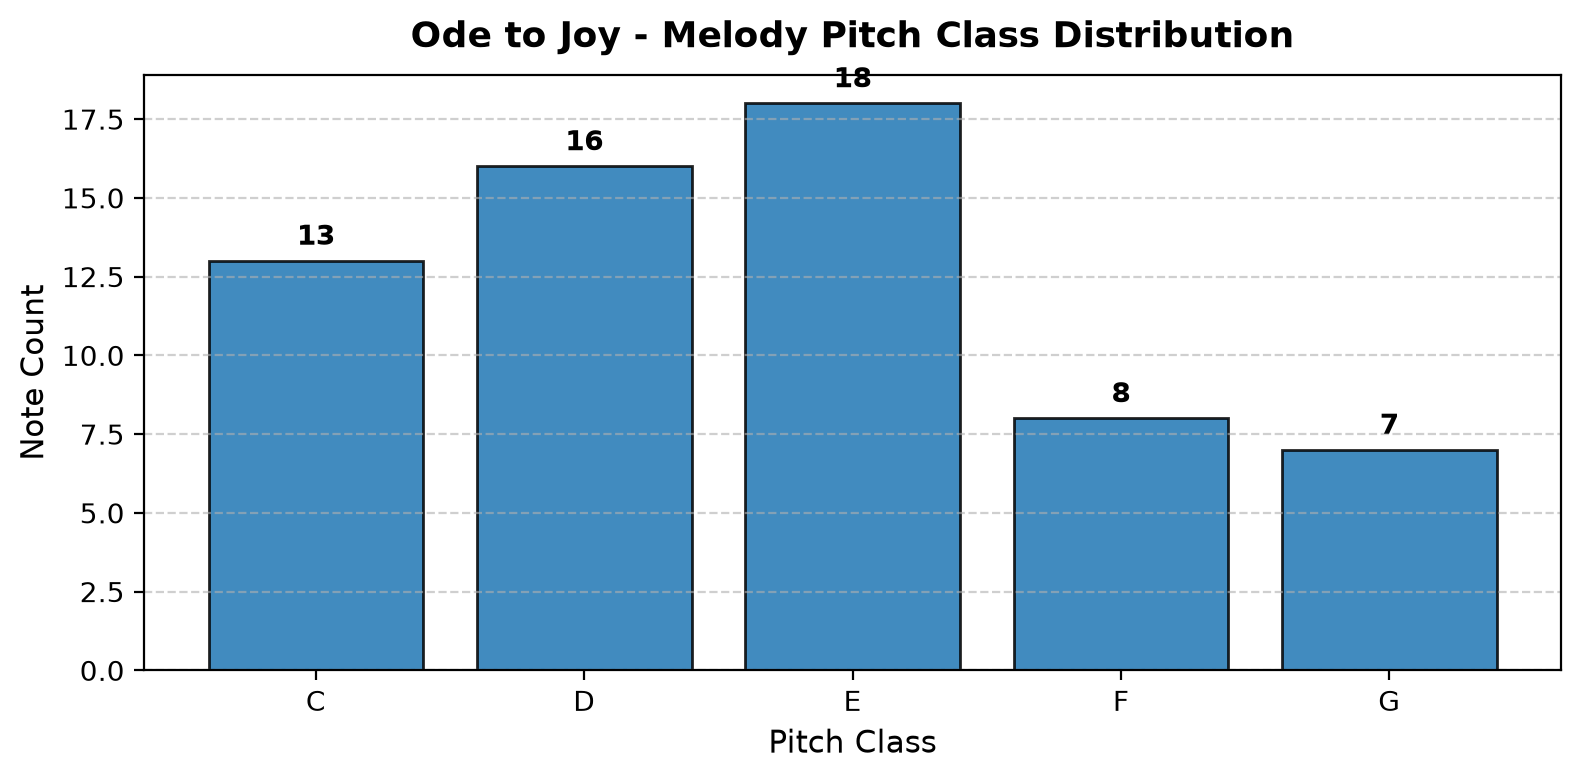

In [10]:
# Collect notes and pitch frequencies
from collections import Counter

melody_pitches = [n.name for n in score.parts[0].flatten().notes]
pitch_counts = Counter(melody_pitches)

# Order pitches across the C major scale
scale_pitches = ['C', 'D', 'E', 'F', 'G']
counts = [pitch_counts.get(p, 0) for p in scale_pitches]

# Plot frequency histogram
plt.figure(figsize=(8, 4))
bars = plt.bar(scale_pitches, counts, color='#1f77b4', edgecolor='black', alpha=0.85)
plt.title('Ode to Joy - Melody Pitch Class Distribution', fontsize=13, fontweight='bold', pad=10)
plt.xlabel('Pitch Class', fontsize=11)
plt.ylabel('Note Count', fontsize=11)
plt.grid(axis='y', linestyle='--', alpha=0.6)

for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2.0, yval + 0.3, int(yval), ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()
